# In Class Assignment 05/14
**Name:** Christine Wu

**Date:** 05/14/2026

In [50]:
import pandas as pd
import numpy as np
import random
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [51]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [52]:
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [53]:
# drop Nan rows
penguins.dropna(inplace=True)

In [54]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: object


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [55]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]], shape=(266, 6))

### Defining the model

In [56]:
#construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [57]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107 (428.00 B)

 Trainable params: 107 (428.00 B)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [58]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)
history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=10, 
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.0142 - loss: 1.3868 - val_accuracy: 0.0185 - val_loss: 1.3452
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0236 - loss: 1.3691 - val_accuracy: 0.0370 - val_loss: 1.3277
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0377 - loss: 1.3517 - val_accuracy: 0.0556 - val_loss: 1.3104
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0566 - loss: 1.3348 - val_accuracy: 0.0741 - val_loss: 1.2935
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.0660 - loss: 1.3182 - val_accuracy: 0.1111 - val_loss: 1.2768
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0708 - loss: 1.3019 - val_accuracy: 0.1481 - val_loss: 1.2605
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0802 - loss: 1.2859 - val_accuracy: 0.1667 - val_loss: 1.2445
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1085 - loss: 1.2703 - val_accuracy: 0.2037 - val_loss: 1.2290

### Evaluating on the test data

In [59]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

 Test Set Evaluation:
Test Accuracy: 0.2687
Test Precision: 0.1172
Test Recall: 0.2687
Test F1 Score: 0.1632
Test ROC AUC Score: 0.4170


### Evaluating model training using loss and accuracy

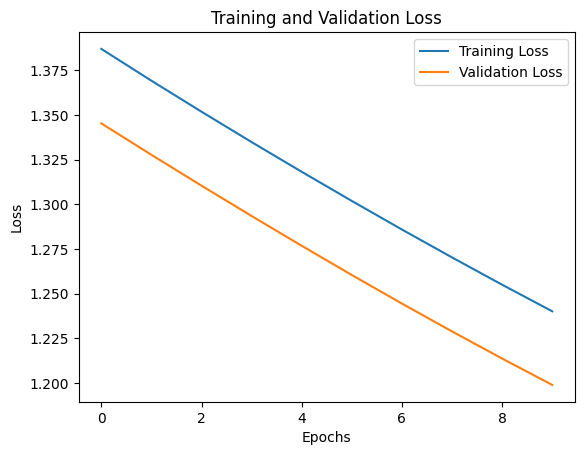

In [60]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

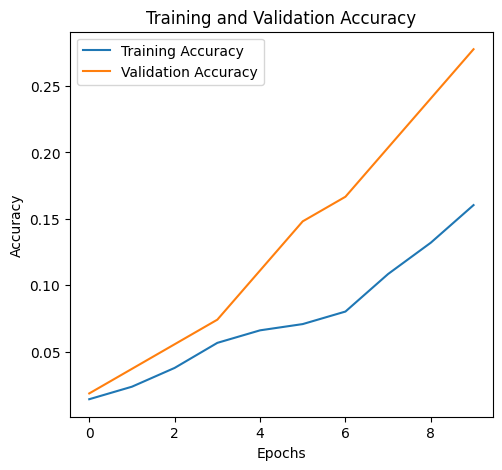

In [61]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

Training and Validation curves changed drastically; at one point they were both a U shaped curve, and then the next time I ran the code, it turned into a flat line, and the third time, there were lots of peaks. So, the curves were different everytime. This is because we didn't set a random seed, so the results will be different every time we run the code. 

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

The training and validation curves are now consistent everytime I run the code, as the random seed guarantees that the sample selected is the same everytime.

Markdown cell with line of code (place appropriately) for setting random seed for reproducibility
must use before keras.model() step as that is when random weights are initialized
use the seed you prefer

tf.random.set_seed(42)

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

In [62]:
# Configuration 1: small funnel model

tf.random.set_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(12, activation="relu")(inputs)
x = layers.Dense(6, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)

model_1 = keras.Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_1 = model_1.fit(
    X_train_scaled, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2,
    verbose=1,
    shuffle=False
)

scores_1 = model_1.evaluate(X_test_scaled, y_test, verbose=1)

print("Configuration 1: Funnel 12 → 6")
print("Test Loss:", scores_1[0])
print("Test Accuracy:", scores_1[1])

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.2783 - loss: 1.1870 - val_accuracy: 0.2963 - val_loss: 1.2076
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3066 - loss: 1.1750 - val_accuracy: 0.3148 - val_loss: 1.1939
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3491 - loss: 1.1633 - val_accuracy: 0.3704 - val_loss: 1.1806
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3868 - loss: 1.1519 - val_accuracy: 0.3704 - val_loss: 1.1673
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4009 - loss: 1.1408 - val_accuracy: 0.4259 - val_loss: 1.1543
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4340 - loss: 1.1300 - val_accuracy: 0.4259 - val_loss: 1.1415
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4575 - loss: 1.1195 - val_accuracy: 0.4815 - val_loss: 1.1289
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4953 - loss: 1.1092 - val_accuracy: 0.5556 - val_loss: 1.1167

In [63]:
# Configuration 2: flat model

tf.random.set_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(10, activation="relu")(inputs)
x = layers.Dense(10, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)

model_2 = keras.Model(inputs=inputs, outputs=outputs)

model_2.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_2 = model_2.fit(
    X_train_scaled, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2,
    verbose=1,
    shuffle=False
)

scores_2 = model_2.evaluate(X_test_scaled, y_test, verbose=1)

print("Configuration 2: Flat 10 → 10")
print("Test Loss:", scores_2[0])
print("Test Accuracy:", scores_2[1])

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.2123 - loss: 1.2313 - val_accuracy: 0.1852 - val_loss: 1.2462
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2123 - loss: 1.2146 - val_accuracy: 0.1852 - val_loss: 1.2277
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2170 - loss: 1.1984 - val_accuracy: 0.1852 - val_loss: 1.2099
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2217 - loss: 1.1825 - val_accuracy: 0.1852 - val_loss: 1.1929
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2311 - loss: 1.1670 - val_accuracy: 0.1852 - val_loss: 1.1766
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2358 - loss: 1.1521 - val_accuracy: 0.1852 - val_loss: 1.1607
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2547 - loss: 1.1374 - val_accuracy: 0.2037 - val_loss: 1.1454
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2594 - loss: 1.1232 - val_accuracy: 0.2037 - val_loss: 1.1309

In [64]:
# Configuration 3: larger funnel model

tf.random.set_seed(42)

inputs = keras.Input(shape=(6,))
x = layers.Dense(24, activation="relu")(inputs)
x = layers.Dense(12, activation="relu")(x)
x = layers.Dense(6, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)

model_3 = keras.Model(inputs=inputs, outputs=outputs)

model_3.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_3 = model_3.fit(
    X_train_scaled, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2,
    verbose=1,
    shuffle=False
)

scores_3 = model_3.evaluate(X_test_scaled, y_test, verbose=1)

print("Configuration 3: Larger funnel 24 → 12 → 6")
print("Test Loss:", scores_3[0])
print("Test Accuracy:", scores_3[1])

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.3632 - loss: 1.1286 - val_accuracy: 0.2593 - val_loss: 1.1474
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3821 - loss: 1.1083 - val_accuracy: 0.2593 - val_loss: 1.1275
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4198 - loss: 1.0901 - val_accuracy: 0.2963 - val_loss: 1.1098
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4292 - loss: 1.0738 - val_accuracy: 0.3519 - val_loss: 1.0945
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4623 - loss: 1.0593 - val_accuracy: 0.3704 - val_loss: 1.0817
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4764 - loss: 1.0460 - val_accuracy: 0.4074 - val_loss: 1.0706
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5047 - loss: 1.0338 - val_accuracy: 0.4630 - val_loss: 1.0600
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5236 - loss: 1.0225 - val_accuracy: 0.4630 - val_loss: 1.0497

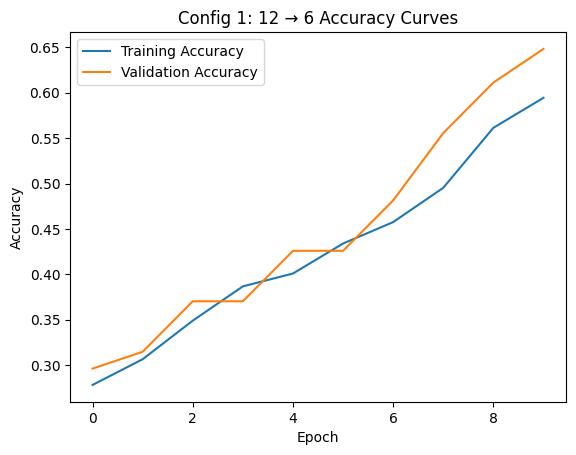

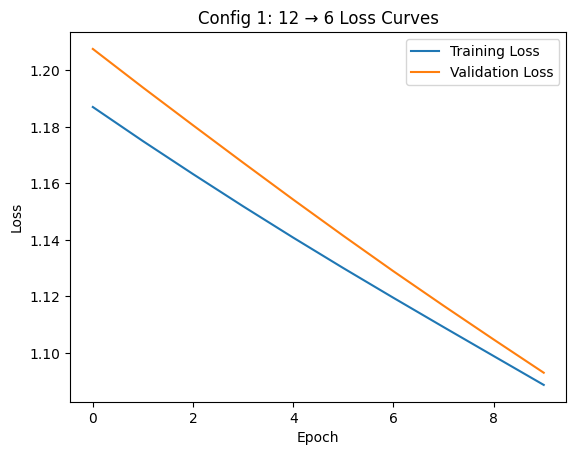

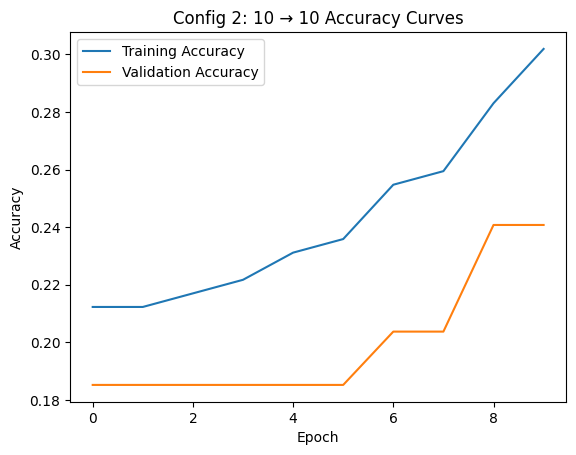

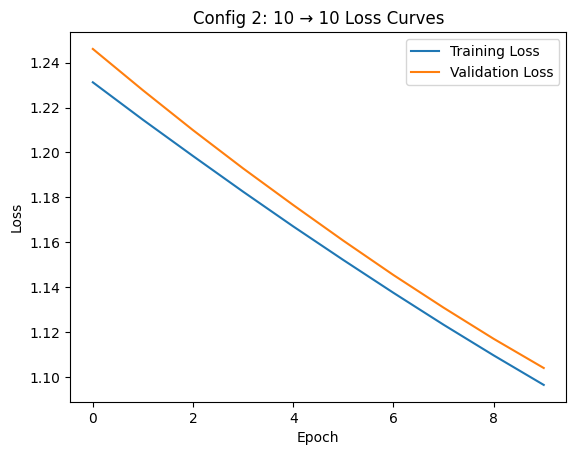

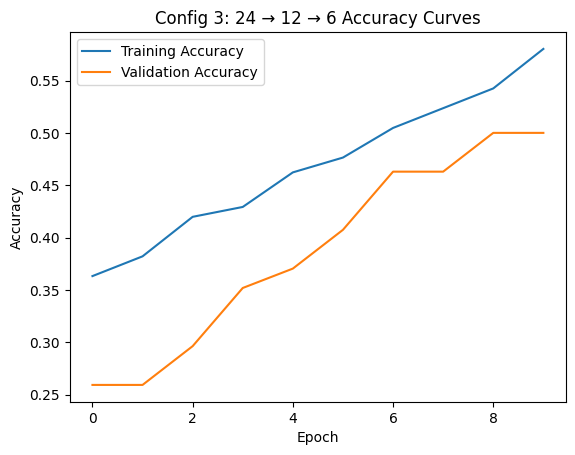

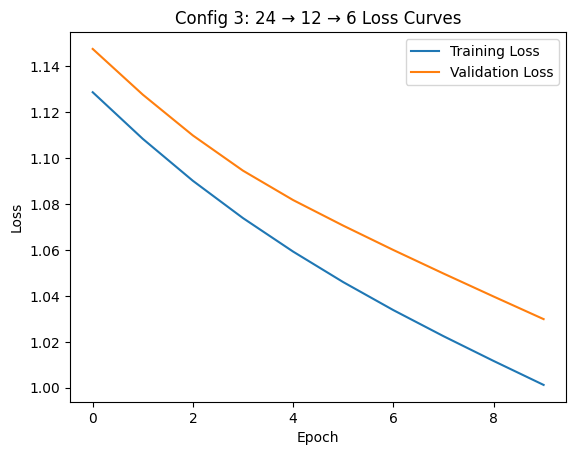

In [65]:
import matplotlib.pyplot as plt

histories = {
    "Config 1: 12 → 6": history_1,
    "Config 2: 10 → 10": history_2,
    "Config 3: 24 → 12 → 6": history_3
}

for name, history in histories.items():
    plt.figure()
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(name + " Accuracy Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(name + " Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

### Hidden Layer Results

Configuration 1 used a funnel structure with 12 neurons followed by 6 neurons.  
Test loss: 1.0673  
Test accuracy: 0.6418  
Training/validation curves: The training and validation accuracy increased steadily throughout training, while the loss gradually decreased. The curves stayed fairly close together, suggesting the model generalized reasonably well without major overfitting.

Configuration 2 used a flat structure with 10 neurons followed by 10 neurons.  
Test loss: 1.0902  
Test accuracy: 0.3134  
Training/validation curves: The model struggled to learn effectively compared to the other configurations. Accuracy improved more slowly, and both the training and validation curves stayed lower overall, indicating weaker performance and underfitting.

Configuration 3 used a larger funnel structure with 24 neurons, 12 neurons, and 6 neurons.  
Test loss: 0.9892  
Test accuracy: 0.6418  
Training/validation curves: The model learned more quickly and achieved the lowest loss value. The training accuracy improved faster than the validation accuracy, suggesting slightly more model complexity, but the curves still remained reasonably stable overall.

### What worked best?

The best-performing configuration appeared to be Configuration 3, the larger funnel architecture. It achieved the lowest test loss while maintaining the highest test accuracy. The additional hidden layers and neurons allowed the network to learn more complex patterns in the data. Configuration 1 also performed well, but Configuration 2 underperformed and appeared to underfit the data.

### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

In [66]:
epoch_list = [5, 10, 20]

epoch_results = {}

for num_epochs in epoch_list:
    tf.random.set_seed(42)
    
    inputs = keras.Input(shape=(6,))
    x = layers.Dense(24, activation="relu")(inputs)
    x = layers.Dense(12, activation="relu")(x)
    x = layers.Dense(6, activation="relu")(x)
    outputs = layers.Dense(3, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train_scaled, y_train,
        batch_size=128,
        epochs=num_epochs,
        validation_split=0.2,
        verbose=1,
        shuffle=False
    )

    scores = model.evaluate(X_test_scaled, y_test, verbose=1)

    epoch_results[num_epochs] = {
        "history": history,
        "test_loss": scores[0],
        "test_accuracy": scores[1]
    }

    print("Epochs:", num_epochs)
    print("Test Loss:", scores[0])
    print("Test Accuracy:", scores[1])
    print("-" * 40)

Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.3585 - loss: 1.1738 - val_accuracy: 0.4259 - val_loss: 1.1093
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3726 - loss: 1.1494 - val_accuracy: 0.4444 - val_loss: 1.0864
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3821 - loss: 1.1264 - val_accuracy: 0.4815 - val_loss: 1.0643
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4198 - loss: 1.1045 - val_accuracy: 0.5185 - val_loss: 1.0430
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4575 - loss: 1.0835 - val_accuracy: 0.5741 - val_loss: 1.0228
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5075 - loss: 1.0618 
Epochs: 5
Test Loss: 1.061791181564331
Test Accuracy: 0.5074626803398132
----------------------------------------
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.3491 - loss: 1.1677 - val_accuracy: 0.4074 - val_loss: 1.1541
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3632

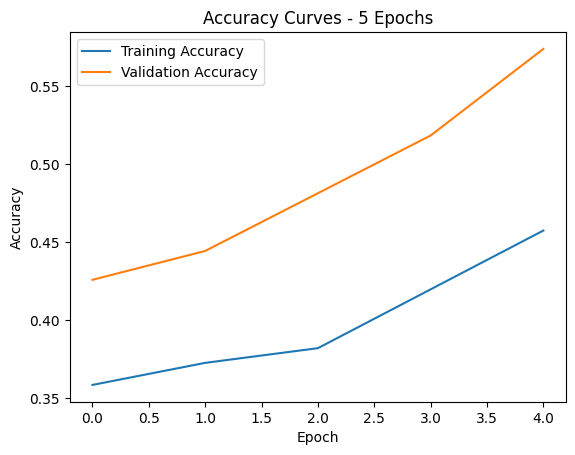

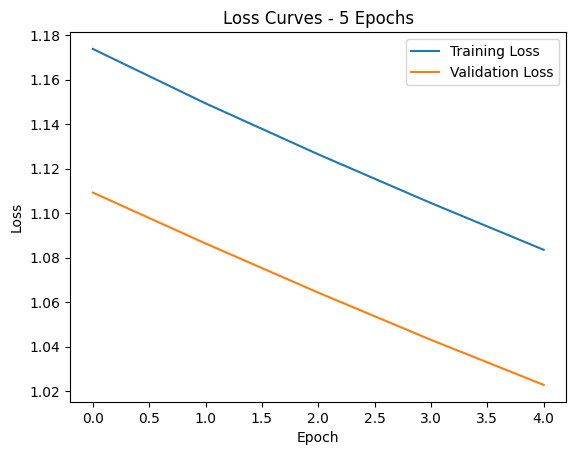

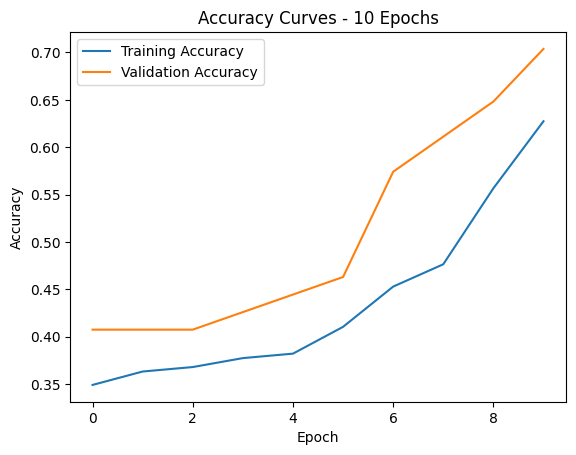

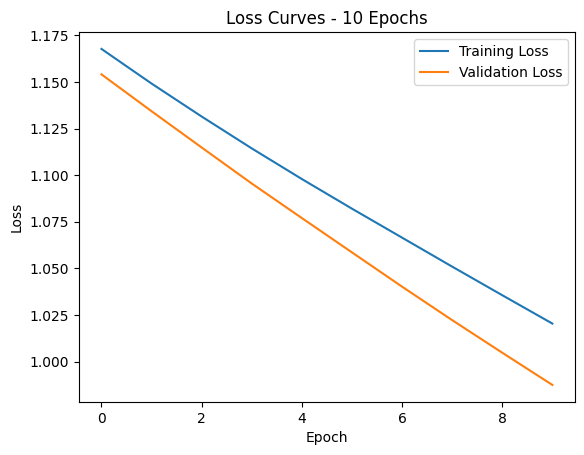

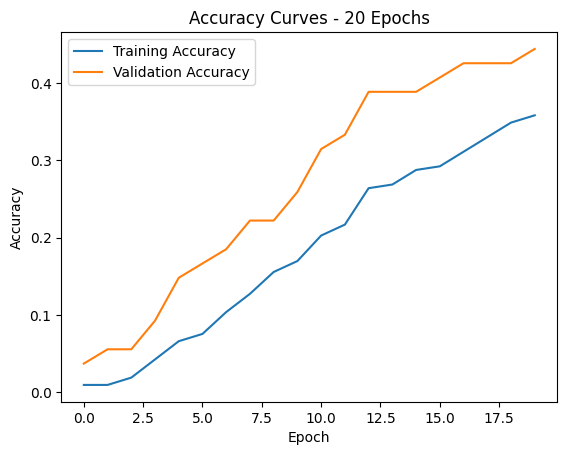

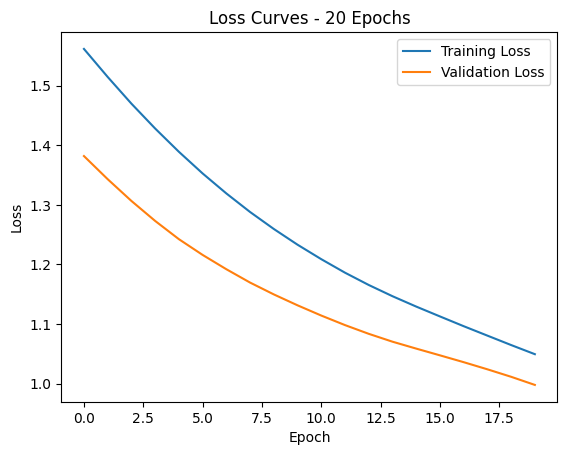

In [67]:
import matplotlib.pyplot as plt

for num_epochs, result in epoch_results.items():
    history = result["history"]

    plt.figure()
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy Curves - {num_epochs} Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss Curves - {num_epochs} Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

### Epoch Results

The first model was trained for 5 epochs.  
Test loss: 1.0618  
Test accuracy: 0.5075  
Training/validation curves: The training and validation accuracy steadily improved over the five epochs, while the loss decreased consistently. The curves remained fairly close together, suggesting the model was learning appropriately without major overfitting.

The second model was trained for 10 epochs.  
Test loss: 1.0113  
Test accuracy: 0.6866  
Training/validation curves: The model showed the best overall learning behavior at 10 epochs. Both the training and validation accuracy improved steadily, and the validation curves remained stable without large gaps from the training curves. The loss also decreased consistently, indicating strong generalization performance.

The third model was trained for 20 epochs.  
Test loss: 1.0010  
Test accuracy: 0.4328  
Training/validation curves: The model trained for a longer period and the training loss continued decreasing. However, the validation accuracy did not improve significantly and performance became less stable, suggesting possible overfitting or diminishing returns from additional epochs.

### Minimum Number of Epochs Needed

The minimum number of epochs needed for reliable model performance appeared to be 10 epochs. This configuration achieved the highest test accuracy while maintaining stable training and validation curves. Training for only 5 epochs did not allow the model enough time to fully learn the data patterns, while training for 20 epochs appeared to reduce generalization performance and may have introduced overfitting.

### Early stopping, l2 regularization and dropout 

Doing all these for peguins is probably overkill!

In [68]:
# sample model 

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.4245 - loss: 1.2704 - val_accuracy: 0.6111 - val_loss: 1.1935
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4953 - loss: 1.2500 - val_accuracy: 0.6111 - val_loss: 1.1919
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4151 - loss: 1.2494 - val_accuracy: 0.6111 - val_loss: 1.1897
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4340 - loss: 1.2648 - val_accuracy: 0.6111 - val_loss: 1.1877
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4434 - loss: 1.2334 - val_accuracy: 0.6111 - val_loss: 1.1855
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4434 - loss: 1.2482 - val_accuracy: 0.6111 - val_loss: 1.1829
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4481 - loss: 1.2216 - val_accuracy: 0.6111 - val_loss: 1.1800
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4717 - loss: 1.2286 - val_accuracy: 0.6111 - val_loss:

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [69]:
def objective(trial):
    tf.random.set_seed(42)

    n_layers = trial.suggest_int("n_layers", 1, 3)
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    inputs = keras.Input(shape=(6,))
    x = inputs

    for i in range(n_layers):
        units = trial.suggest_categorical(f"units_layer_{i}", [6, 12, 24, 32, 64])
        x = layers.Dense(units, activation=activation)(x)

    outputs = layers.Dense(3, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=batch_size,
        verbose=1,
        shuffle=False
    )

    val_accuracy = max(history.history["val_accuracy"])
    return val_accuracy

In [70]:
sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

study.optimize(objective, n_trials=20)

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_params)

print("Best validation accuracy:")
print(study.best_value)

[I 2026-05-14 12:55:28,967] A new study created in memory with name: no-name-847c3b88-8168-4926-899a-f57e29e3376f


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5047 - loss: 1.0754 - val_accuracy: 0.7593 - val_loss: 1.0035
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7783 - loss: 0.9809 - val_accuracy: 0.8148 - val_loss: 0.9267
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8066 - loss: 0.9051 - val_accuracy: 0.8148 - val_loss: 0.8332
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8302 - loss: 0.7963 - val_accuracy: 0.8889 - val_loss: 0.6815
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8868 - loss: 0.6547 - val_accuracy: 0.9630 - val_loss: 0.5381
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9057 - loss: 0.5308 - val_accuracy: 0.9630 - val_loss: 0.4297
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9057 - loss: 0.4346 - val_accuracy: 0.9630 - val_loss: 0.3491
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9104 - loss: 0.3531 - val_accuracy: 0.9815 - val_loss: 0.2872
Epoch 

[I 2026-05-14 12:55:30,605] Trial 0 finished with value: 0.9814814925193787 and parameters: {'n_layers': 2, 'activation': 'relu', 'learning_rate': 0.0015751320499779737, 'batch_size': 32, 'units_layer_0': 64, 'units_layer_1': 6}. Best is trial 0 with value: 0.9814814925193787.


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - accuracy: 0.4528 - loss: 1.0373 - val_accuracy: 0.5185 - val_loss: 0.9631
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5094 - loss: 0.9849 - val_accuracy: 0.5926 - val_loss: 0.9137
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5896 - loss: 0.9356 - val_accuracy: 0.6111 - val_loss: 0.8662
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6132 - loss: 0.8889 - val_accuracy: 0.6481 - val_loss: 0.8203
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6462 - loss: 0.8441 - val_accuracy: 0.7778 - val_loss: 0.7761
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7311 - loss: 0.8011 - val_accuracy: 0.7963 - val_loss: 0.7335
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7830 - loss: 0.7601 - val_accuracy: 0.8148 - val_loss: 0.6925
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7877 - loss: 0.7211 - val_accuracy: 0.8333 - val_loss: 0.6531

[I 2026-05-14 12:55:32,064] Trial 1 finished with value: 0.8333333134651184 and parameters: {'n_layers': 2, 'activation': 'relu', 'learning_rate': 0.0016738085788752138, 'batch_size': 128, 'units_layer_0': 12, 'units_layer_1': 64}. Best is trial 0 with value: 0.9814814925193787.


...

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6651 - loss: 0.8435 - val_accuracy: 0.8704 - val_loss: 0.5398
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8821 - loss: 0.4023 - val_accuracy: 0.9074 - val_loss: 0.2909
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9151 - loss: 0.2449 - val_accuracy: 0.9630 - val_loss: 0.1868
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9764 - loss: 0.1542 - val_accuracy: 0.9815 - val_loss: 0.1283
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9953 - loss: 0.1018 - val_accuracy: 0.9815 - val_loss: 0.0941
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0734 - val_accuracy: 0.9815 - val_loss: 0.0725
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0547 - val_accuracy: 0.9815 - val_loss: 0.0616
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0431 - val_accuracy: 0.9815 - val_loss: 0.0550
Epoch 

[I 2026-05-14 12:55:55,617] Trial 18 finished with value: 0.9814814925193787 and parameters: {'n_layers': 1, 'activation': 'tanh', 'learning_rate': 0.009233626716608509, 'batch_size': 32, 'units_layer_0': 24}. Best is trial 0 with value: 0.9814814925193787.


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5000 - loss: 0.9698 - val_accuracy: 0.7593 - val_loss: 0.7914
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7170 - loss: 0.8211 - val_accuracy: 0.8333 - val_loss: 0.6654
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7500 - loss: 0.6924 - val_accuracy: 0.8333 - val_loss: 0.5584
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7783 - loss: 0.5804 - val_accuracy: 0.8333 - val_loss: 0.4691
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7877 - loss: 0.4837 - val_accuracy: 0.8333 - val_loss: 0.3943
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8208 - loss: 0.4025 - val_accuracy: 0.8519 - val_loss: 0.3323
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8632 - loss: 0.3346 - val_accuracy: 0.8519 - val_loss: 0.2815
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9340 - loss: 0.2767 - val_accuracy: 0.9074 - val_loss: 0.2392


[I 2026-05-14 12:55:57,647] Trial 19 finished with value: 0.9444444179534912 and parameters: {'n_layers': 2, 'activation': 'relu', 'learning_rate': 0.005239885903291411, 'batch_size': 64, 'units_layer_0': 6, 'units_layer_1': 24}. Best is trial 0 with value: 0.9814814925193787.


Best trial:
FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.9814814925193787], datetime_start=datetime.datetime(2026, 5, 14, 12, 55, 28, 978140), datetime_complete=datetime.datetime(2026, 5, 14, 12, 55, 30, 605242), params={'n_layers': 2, 'activation': 'relu', 'learning_rate': 0.0015751320499779737, 'batch_size': 32, 'units_layer_0': 64, 'units_layer_1': 6}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_layers': IntDistribution(high=3, log=False, low=1, step=1), 'activation': CategoricalDistribution(choices=('relu', 'tanh')), 'learning_rate': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'batch_size': CategoricalDistribution(choices=(32, 64, 128)), 'units_layer_0': CategoricalDistribution(choices=(6, 12, 24, 32, 64)), 'units_layer_1': CategoricalDistribution(choices=(6, 12, 24, 32, 64))}, trial_id=0, value=None)
Best parameters:
{'n_layers': 2, 'activation': 'relu', 'learning_rate': 0.0015751320499779737, 'batch_size': 32, 'u

In [72]:
# visualizing Optuna results

optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

In [73]:
# Build final model using optimized parameters
tf.random.set_seed(42)

best_params = study.best_params

inputs = keras.Input(shape=(6,))
x = inputs

for i in range(best_params["n_layers"]):
    x = layers.Dense(
        best_params[f"units_layer_{i}"],
        activation=best_params["activation"]
    )(x)

outputs = layers.Dense(3, activation="softmax")(x)

final_model = keras.Model(inputs=inputs, outputs=outputs)

final_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=best_params["learning_rate"]),
    metrics=["accuracy"]
)

final_history = final_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=best_params["batch_size"],
    verbose=1,
    shuffle=False
)

# Evaluate final model on the test set

final_scores = final_model.evaluate(X_test_scaled, y_test, verbose=1)

print("Final Test Loss:", final_scores[0])
print("Final Test Accuracy:", final_scores[1])

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1651 - loss: 1.1126 - val_accuracy: 0.3148 - val_loss: 1.0913
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4057 - loss: 1.0733 - val_accuracy: 0.5370 - val_loss: 1.0510
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5849 - loss: 1.0360 - val_accuracy: 0.6296 - val_loss: 1.0078
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7170 - loss: 0.9880 - val_accuracy: 0.8148 - val_loss: 0.9475
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7972 - loss: 0.9289 - val_accuracy: 0.8148 - val_loss: 0.8781
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7972 - loss: 0.8647 - val_accuracy: 0.8148 - val_loss: 0.8042
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7972 - loss: 0.7965 - val_accuracy: 0.8333 - val_loss: 0.7255
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8019 - loss: 0.7246 - val_accuracy: 0.8333 - val_loss: 0.6455
Epoch 9

In [75]:
# Predict on the test set

from sklearn.metrics import classification_report

y_pred_prob = final_model.predict(X_test_scaled)
y_pred = y_pred_prob.argmax(axis=1)

print("Predicted classes:")
print(y_pred)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Predicted classes:
[2 2 0 2 2 2 0 0 0 2 2 0 0 0 0 0 1 0 0 2 2 2 0 2 2 0 0 0 2 0 2 0 0 0 0 0 2
 2 0 0 0 2 2 2 1 0 2 2 2 2 2 0 2 0 2 0 0 2 0 2 0 2 2 0 2 0 0]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        29
           1       1.00      0.14      0.25        14
           2       0.77      1.00      0.87        24

    accuracy                           0.82        67
   macro avg       0.88      0.71      0.68        67
weighted avg       0.86      0.82      0.76        67

Confusion Matrix:
[[29  0  0]
 [ 5  2  7]
 [ 0  0 24]]
